In [72]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import numpy as np

In [73]:
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
device

'mps'

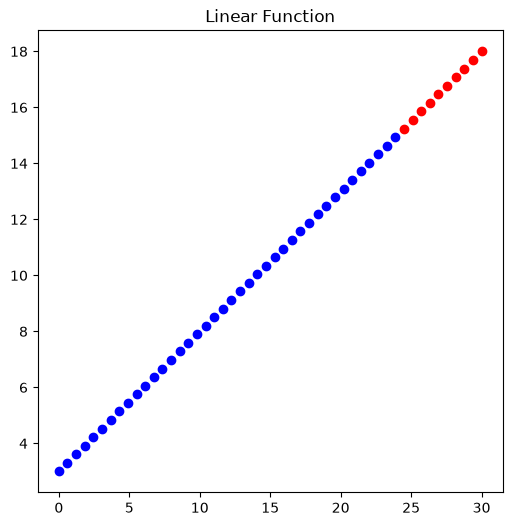

In [74]:
a = 0.5
b = 3

x = torch.linspace(0,30,50).unsqueeze(1)
y = a*x + b

data_size = x.size()[0]
ratio = int(data_size*0.8)
x_train = x[:ratio]
y_train = y[:ratio]

x_test = x[ratio:]
y_test = y[ratio:]

plt.figure(1, figsize=(6,6))
plt.scatter(x_train,y_train, c='b', marker='o', label='Train')
plt.scatter(x_test,y_test, c='r', marker='o', label='Test')
plt.title('Linear Function')
plt.show()

In [75]:
class LinearFunctionRegression(nn.Module):
    def __init__(self):
        super().__init__()

        #self.weights = nn.Parameter(torch.randn(1))
        #self.bias = nn.Parameter(torch.randn(1))
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

In [76]:
model = LinearFunctionRegression()

loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [77]:
x_train = x_train.to(device)
y_train = y_train.to(device)
x_test = x_test.to(device)
y_test = y_test.to(device)
model = model.to(device)

In [78]:
epochs = 200
losses_train = []
losses_test = []

for epoch in range(epochs):
    model.train()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_train.append(loss.item())

    model.eval()
    with torch.inference_mode():
        y_pred = model(x_test)
        loss = loss_fn(y_pred, y_test)
        losses_test.append(loss.item())

    print(f'Epoch {epoch+1}/{epochs}, Training/Test Loss: {losses_train[-1]} {losses_test[-1]}')

Epoch 1/200, Training/Test Loss: 7.0537824630737305 10.010560989379883
Epoch 2/200, Training/Test Loss: 5.618438720703125 6.747853755950928
Epoch 3/200, Training/Test Loss: 4.1830949783325195 3.4851455688476562
Epoch 4/200, Training/Test Loss: 2.747750759124756 0.2224387228488922
Epoch 5/200, Training/Test Loss: 1.3124077320098877 3.040268659591675
Epoch 6/200, Training/Test Loss: 1.170162320137024 1.213247537612915
Epoch 7/200, Training/Test Loss: 0.9083689451217651 1.3511924743652344
Epoch 8/200, Training/Test Loss: 0.906620979309082 1.2551088333129883
Epoch 9/200, Training/Test Loss: 0.903944194316864 1.393052339553833
Epoch 10/200, Training/Test Loss: 0.9038518071174622 1.0712807178497314
Epoch 11/200, Training/Test Loss: 0.9060961008071899 1.451594352722168
Epoch 12/200, Training/Test Loss: 0.9030696749687195 1.1298224925994873
Epoch 13/200, Training/Test Loss: 0.8993160128593445 1.5101346969604492
Epoch 14/200, Training/Test Loss: 0.902287483215332 1.1883630752563477
Epoch 15/200

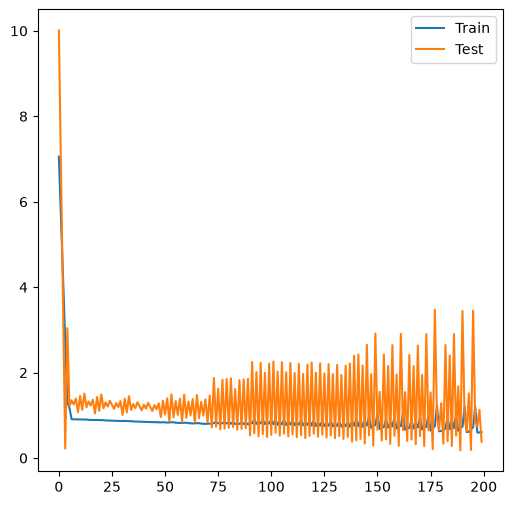

In [79]:
plt.figure(1, figsize=(6,6))
plt.plot(losses_train, label='Train')
plt.plot(losses_test, label='Test')
plt.legend()
plt.show()

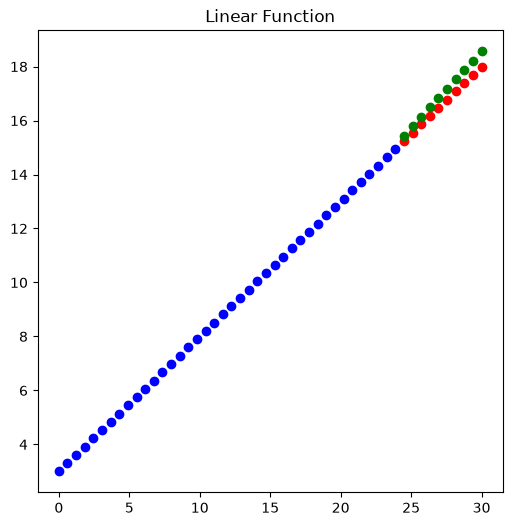

In [80]:
model.eval()
with torch.no_grad():
    y_preds = model(x_test)

plt.figure(1, figsize=(6,6))
plt.scatter(x_train.cpu(),y_train.cpu(), c='b', marker='o', label='Train')
plt.scatter(x_test.cpu(),y_test.cpu(), c='r', marker='o', label='Train')
plt.scatter(x_test.cpu(),y_preds.cpu(), c='g', marker='o', label='Test')
plt.title('Linear Function')
plt.show()

In [81]:
list(model.parameters())

[Parameter containing:
 tensor([[0.5657]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([1.5914], device='mps:0', requires_grad=True)]

In [82]:
y_preds

tensor([[15.4453],
        [15.7916],
        [16.1380],
        [16.4843],
        [16.8307],
        [17.1770],
        [17.5234],
        [17.8697],
        [18.2161],
        [18.5624]], device='mps:0')